In [6]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as random
from scipy.signal import convolve
import scipy
from joblib import Parallel, delayed
import time
import sys
from scipy import sparse
import json
from tqdm import tqdm, tqdm_notebook
import matplotlib.gridspec as gridspec
import os
sys.path.insert(0, "../Scripts")
# from antigenicWaveSimulationMethods import main as coEvoSimulation
from coverage import elementwise_coverage_vectorized, coverage_1D, elementwise_coverage, split_coverage
from fitness import fitness, norm_fitness, phage_growth, norm_fitness_2D
# from altImmunity import immunity_loss_uniform, immunity_gain_from_kernel
from immunity import immunity_mean_field_add, immunity_mean_field_remove
from initMethods import init_trail_nh, init_dict_kernel, init_guassian_n, init_cond
from supMethods import time_conv, write2json, sum_parallel
from mutation import mutation
from randomHGT import HGT_logistic_event

In [9]:
params = { #parameters relevant for the equations
        "Nh":                     1E5,
        "N0":                     1E9, #This Will be updated by self-consitent solution
        "R0":                      20, 
        "M":                       10, #Also L, total number of spacers
        "mu":                      50, #mutation rate
        "gamma_shape":             20,
        "Np":                     100, #Number of Cas Protein
        "dc":                      10, #Required number of complexes to activate defence
        "h":                       10, #coordination coeff
        "r":                     1000, #cross-reactivity kernel
        "beta":                     0,
        "rate_HGT":                 0,
        "HGT_bonus_acq_ratio":      0,
        "rate_recovery":            0,
        "HGT_type":                 0,
        "n_spacer":                 1,
        "A":                      0.5,
    }
sim_params = { #parameters relevant for the simulation (including Inital Valuess)
        "continue":                 False, #DO NOT CREATE ARBITRARY FOLDERS ONLY FOR TESTS
        "xdomain":                   5000,
        "dx":                           1,
        "tf":                        1000,
        "dt":                           1,
        "dt_exact_fitness":             1,
        "dt_snapshot":                  1,
        "initial_mean_n":           [0,0],
        "initial_mean_nh":          [0,0],
        "conv_size":                 2000,
        "num_threads":                 32,
        "foldername":     "../Data_2D_Test11",
        "seed":                       128,
        "hard_N0":                   False,
        "ndim":                         2,
    }

In [10]:
params, sim_params = init_cond(params, sim_params)
foldername = sim_params["foldername"]

try:
    write2json(foldername, params, sim_params)
except FileNotFoundError:
    os.mkdir(foldername)
    write2json(foldername, params, sim_params)


Assumptions Checks: 
mu >> 1 : mu = 50 >> 1
del_x << r : gamma_shape = 20 << r = 1000
v*tau >> sigma : v*tau = 1786.047227736843 >> sigma = 54.006255824666034
uc << r : uc = 178.43622806470373 << r = 1000


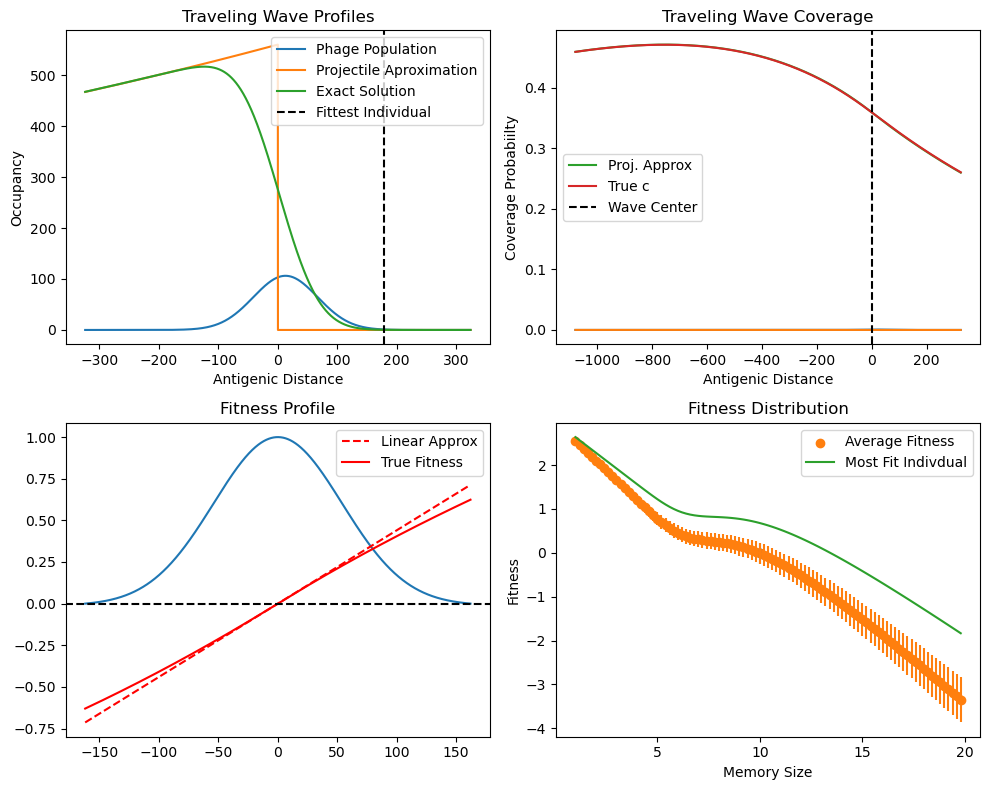

In [11]:
from formulas import plot_fitness_memory_dynamics, plot_wave_coverage, plot_wave_fitness, plot_wave_profiles
fig = plt.figure(figsize=(10, 8))

# Define the grid layout with 3 rows and 3 columns
gs = gridspec.GridSpec(2, 2)

# Create the first two rows (2x2 grid)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Plot something in each subplot
plot_wave_profiles(params, sim_params, ax1)
plot_wave_coverage(params, sim_params, ax2)
plot_wave_fitness(params, sim_params, ax3)
plot_fitness_memory_dynamics(params, sim_params, ax4)

# Adjust the layout
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
from formulas import gaussian1D, semi_exact_nh
from initMethods import init_full_kernel, init_quarter_kernel
xdomain = np.arange(-sim_params["xdomain"], sim_params["xdomain"], sim_params["dx"])

st1 = time.time()
n = init_guassian_n(params, sim_params, t = 10)
nh = init_trail_nh(params, sim_params, exact=True)
kernel_dict = init_dict_kernel(params, sim_params)

if params["beta"] != 0:
    kernel_acq_dict = init_dict_kernel(params, sim_params, "beta")

kernel_quarter = init_quarter_kernel(params, sim_params)
kernel_full = init_full_kernel(params, sim_params)
ed = time.time()
            
nh_total = params["Nh"]
n_total = params["N"]
uc = params["uc"]
sigma = params["sigma"]
M0 = params["M0"]
t = 0

folder = sim_params["foldername"]

# n = np.load(folder + "/frame_n0.npy")
with open(foldername+'/runtime_stats.txt','w') as file:
    file.write(f't: {t}| init_functions: {time_conv(ed-st1)}| Phage Population: {n_total:.4f}| Spacer Population: {nh_total:.4f}| Uc: {uc:.4f}| sigma: {sigma:.4f}| M0: {M0:.4f} \n')

In [ ]:
from coverage import double_vectorized_coverage


while(t < sim_params["tf"]):

    if (t%sim_params["dt_snapshot"] == 0):
        sparse.save_npz(foldername+f"/sp_frame_n{t}",n.tocoo())
        sparse.save_npz(foldername+f"/sp_frame_nh{t}",nh.tocoo())
        
    st1 = time.time()

    if params["beta"] != 0:
        p, int_prob = double_vectorized_coverage(nh, n, kernel_dict, kernel_acq_dict, params, sim_params)
    else:
        p = elementwise_coverage_vectorized(nh, n, kernel_dict, params, sim_params)

    st2 = time.time()
    f = fitness(n, p, params, sim_params)
    f, f_avg = norm_fitness_2D(f, n, params, sim_params, return_avg = True)
    n = phage_growth(n, f, params, sim_params, True) #update
            
    if (np.sum(n) <= 1) or (np.sum(n) >= (2)*params["N0"]):
        with open(foldername+'/runtime_stats.txt','a') as file:
            outstring = f"DEAD at: {t}| N: {np.sum(n)}| Coverage: {time_conv(st2-st1)}| Growth: {time_conv(st3-st2)}| Mutation: {time_conv(st4-st3)}| Immunity: {time_conv(ed-st4)}| f average: {f_avg}\n"
            file.write(outstring)
            break

    st3 = time.time()
    n = mutation(n, params, sim_params)

    st4 = time.time()
    nh_prev = nh

    if params["beta"] != 0:
        nh_temp = immunity_mean_field_add(nh, n, params, sim_params, int_prob=int_prob)
    else:
        nh_temp = immunity_mean_field_add(nh, n, params, sim_params)
    nh = immunity_mean_field_remove(nh_temp, n, params, sim_params)

    diff_of_acquisition = 0
    ed = time.time()

    with open(foldername+'/runtime_stats.txt','a') as file:
        M = params["M"]
        outstring = f"t: {t}| N: {np.sum(n)}| Coverage: {time_conv(st2-st1)}| Growth: {time_conv(st3-st2)}| Mutation: {time_conv(st4-st3)}| Immunity: {time_conv(ed-st4)}| M: {M:.4f}| f average: {f_avg} \n"
        file.write(outstring)

    t += sim_params["dt"]

(-100.0, 100.0)

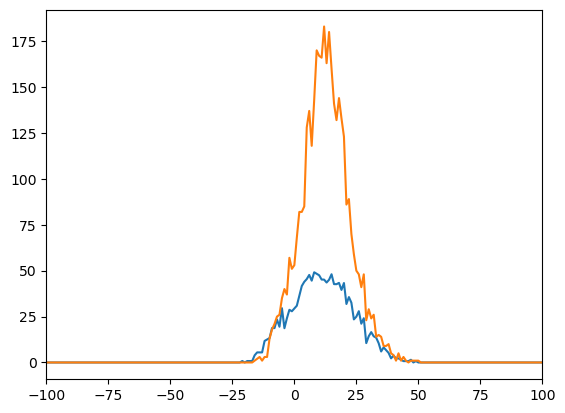

In [ ]:
plt.plot(xdomain, np.sum(p.toarray(), axis = 1))
plt.plot(xdomain, np.sum(n.toarray(), axis = 1))
plt.xlim(-100, 100)

In [ ]:
from analysis import analysis
from analysisMethods import get_tdomain

dt = 10
GMM_flag = 0
margin = 0.0
input_flag = False
subfolder_flag = True
to_plot = False

t_domain = get_tdomain(foldername,to_plot=False, t0 = 0, margins = (margin, margin), dt = dt)

In [ ]:
foldername

'../Data_2D_Test8'

In [ ]:
analysis(foldername, dt, plot_flag = True, margin = 0.4, GMM_flag = GMM_flag)